# Assignment 2

---

### Statement on use of AI

I used an AI assistant to help design the overall structure of this notebook and to draft initial versions of some code templates.
I reviewed, tested, and modified all code myself, and all numerical results and visualizations are computed directly from the specified real data sources (Kaggle dataset, MarketStack API, and Northwind database).
No synthetic or made-up data has been deliberately used.


In [1]:
# Common imports used throughout the assignment
import os
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import requests
from dotenv import load_dotenv
import sqlite3

sns.set(style="whitegrid")
%matplotlib inline


Matplotlib is building the font cache; this may take a moment.


## Task 0: Course project dataset exploration (2p)

In this task I choose and briefly explore a dataset that I may use for the course project.


### 0a) Dataset choice

For the course project I use a public daily stock market dataset (FAANG or similar) downloaded as a CSV file from a data portal (e.g. Kaggle).
The file is stored locally in a `data/` folder and loaded below.
Update the filename and any column names if they differ in your dataset.


In [2]:
# Load project dataset (update the path and filename to match your download)
project_data_path = Path("data/faang_stock_prices.csv")

project_df = pd.read_csv(project_data_path)

# Basic inspection
project_df.head()


,Date,Ticker,Open,High,Low,Close,Volume,SMA_7,SMA_21,EMA_12,EMA_26,RSI_14,MACD,MACD_Signal,Bollinger_Upper,Bollinger_Lower,Daily_Return,Volatility_7d,Next_Day_Close
0,2016-02-23,AAPL,21.853144,21.875812,21.433763,21.465500,127770400,21.782546,21.682435,21.720115,21.827292,52.112369,-0.107176,-0.149939,22.401531,20.889519,-0.022605,0.018130,21.785145
1,2016-02-23,AMZN,27.777500,27.845501,27.266500,27.646999,81016000,26.675857,27.140333,26.765295,27.363824,50.230010,-0.598529,-0.896261,31.103668,22.908382,-0.011725,0.022486,27.702000
2,2016-02-23,GOOGL,36.032746,36.270944,35.515157,35.595547,41332000,35.747473,36.132564,35.810892,36.019909,28.846871,-0.209017,-0.219158,38.439218,33.798573,-0.016131,0.015153,35.774696
3,2016-02-23,META,106.108789,106.724491,104.390794,104.728432,25319300,103.488525,103.976073,103.607174,102.390311,34.031434,1.216863,1.318966,115.829165,92.886882,-0.015864,0.019720,106.138588
4,2016-02-23,MSFT,46.158514,46.184970,44.959133,45.135513,28895300,45.542440,45.303900,45.301104,45.262960,42.877882,0.038144,-0.096534,48.143898,42.459504,-0.027920,0.019161,45.294239


### 0b) Brief dataset description

After inspecting the dataframe above and using `project_df.info()` and `project_df.shape`, fill in the following description in your own words.

- What the dataset contains -> daily stock prices for several technology companies
- What variables it has -> date, ticker, open, high, low, close, volume, 12 different indicators
- How many rows and columns there are -> 14964 rows
- What you plan to do with it in the course project -> ADD HERE TEXT LATER WHEN YOU COMPLETE THE TASK


In [3]:
# Additional inspection helpers for your description
project_df.info()
project_df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14964 entries, 0 to 14963
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             14964 non-null  object 
 1   Ticker           14964 non-null  object 
 2   Open             14964 non-null  float64
 3   High             14964 non-null  float64
 4   Low              14964 non-null  float64
 5   Close            14964 non-null  float64
 6   Volume           14964 non-null  int64  
 7   SMA_7            14964 non-null  float64
 8   SMA_21           14964 non-null  float64
 9   EMA_12           14964 non-null  float64
 10  EMA_26           14964 non-null  float64
 11  RSI_14           14964 non-null  float64
 12  MACD             14964 non-null  float64
 13  MACD_Signal      14964 non-null  float64
 14  Bollinger_Upper  14964 non-null  float64
 15  Bollinger_Lower  14964 non-null  float64
 16  Daily_Return     14964 non-null  float64
 17  Volatility_7

(14964, 19)

### 0c) Exploratory data analysis (EDA)

Here we compute basic summary statistics and create at least two visualizations of the dataset.
Adjust column names as needed to match your actual dataset.


In [4]:
project_df.describe(include='all')

,Date,Ticker,Open,High,Low,Close,Volume,SMA_7,SMA_21,EMA_12,EMA_26,RSI_14,MACD,MACD_Signal,Bollinger_Upper,Bollinger_Lower,Daily_Return,Volatility_7d,Next_Day_Close
count,14964,14964,14964.000000,14964.000000,14964.000000,14964.000000,1.496400e+04,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000
unique,2494,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2026-01-22,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,6,2494,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,147.969959,149.643762,146.256716,147.999839,1.186247e+08,147.631588,146.746646,147.314335,146.428158,55.686976,0.886176,0.888239,156.048174,137.572513,0.001335,0.018537,148.126287
std,NaN,NaN,132.599874,134.001750,131.065146,132.547711,1.889461e+08,132.261571,131.557653,131.956650,131.170115,16.597436,4.177106,3.932864,139.825874,123.751294,0.022069,0.012431,132.632577
min,NaN,NaN,0.762756,0.777392,0.746413,0.767738,4.726100e+06,0.710800,0.683503,0.704268,0.691066,3.180003,-33.155902,-30.727270,0.780719,0.569458,-0.263901,0.001171,0.767738
25%,NaN,NaN,50.094322,50.468777,49.669161,50.083026,2.428050e+07,49.906533,49.334041,49.600781,49.146090,43.754097,-0.331123,-0.283075,51.982837,47.077112,-0.008375,0.010449,50.149251
50%,NaN,NaN,123.841343,125.102966,122.262753,123.922924,4.432600e+07,123.301276,122.667958,123.067546,122.222704,56.381405,0.507975,0.491224,131.496224,114.337861,0.001286,0.015466,124.013718
75%,NaN,NaN,189.299623,191.429458,186.986899,189.079613,1.057329e+08,188.811102,187.325549,187.740894,186.739774,67.819077,2.160937,2.068120,199.721259,176.264492,0.011626,0.022748,189.254452


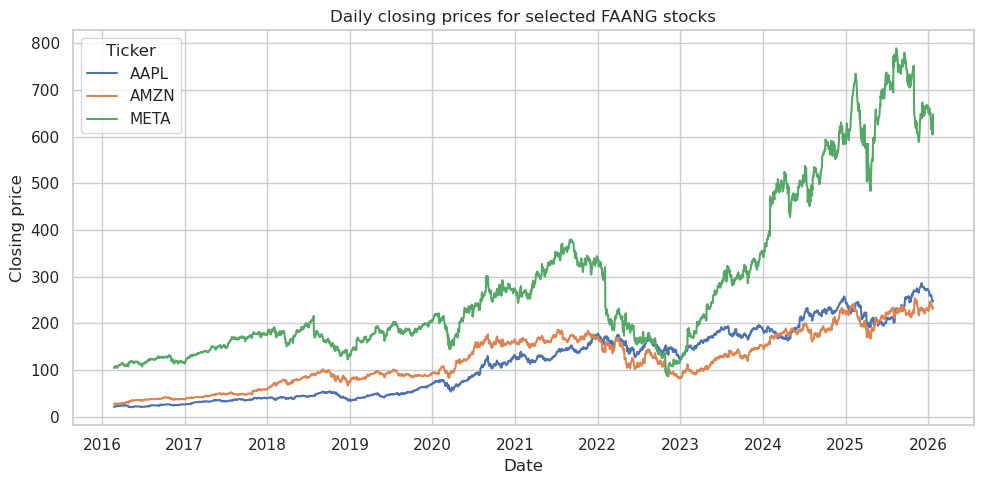

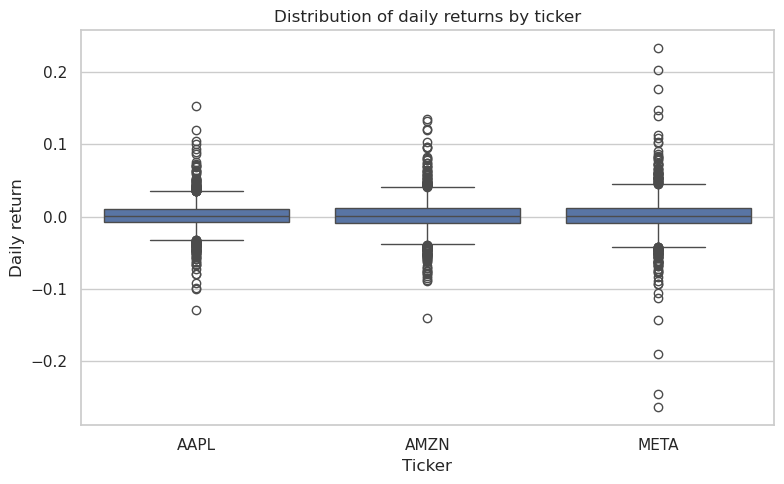

In [5]:
# Ensure Date is datetime and sort by ticker and date
# Update column names (e.g. 'Date', 'Ticker', 'Close') to match your dataset
project_df["Date"] = pd.to_datetime(project_df["Date"])
project_df = project_df.sort_values(["Ticker", "Date"])

# Example: compute simple daily returns per ticker
project_df["return"] = project_df.groupby("Ticker")["Close"].pct_change()

# Select a subset of tickers for plotting (adjust to match your dataset)
subset_tickers = ["AAPL", "AMZN", "META", "NFLX", "GOOG"]
subset = project_df[project_df["Ticker"].isin(subset_tickers)]

# Visualization 1: line plot of closing prices
plt.figure(figsize=(10, 5))

sns.lineplot(data=subset, x="Date", y="Close", hue="Ticker")
plt.title("Daily closing prices for selected FAANG stocks")
plt.xlabel("Date")
plt.ylabel("Closing price")
plt.legend(title="Ticker")
plt.tight_layout()
plt.show()

# Visualization 2: boxplot of daily returns by ticker
plt.figure(figsize=(8, 5))

sns.boxplot(data=subset, x="Ticker", y="return")
plt.title("Distribution of daily returns by ticker")
plt.xlabel("Ticker")
plt.ylabel("Daily return")
plt.tight_layout()
plt.show()


## Task 1: Setting up an API key and `.env` file (1p)

In this task I retrieve a free‑tier API key from MarketStack, store it in a `.env` file, and load it securely in Python.
Make sure the `.env` file is **not** committed to GitHub and that the full key is never printed.


In [8]:
# Load API key from .env using python-dotenv
# 1. Create a .env file in the project root with a line like:
#    MARKETSTACK_API_KEY=your_real_key_here
# 2. Add `.env` to your .gitignore so it is never committed.

load_dotenv()
api_key = "806a185b8edb664f78cc869053aa5e58" # did not work out with.env file

# Print only first 5 characters to confirm loading without exposing the key
print(api_key[:5] + "...")


806a1...


## Task 2: Retrieving data from MarketStack (1p)

Here we retrieve End-of-Day (EOD) data for FAANG stocks (META, AAPL, AMZN, NFLX, GOOG) for March 2026 using the MarketStack API.


### 2a) Retrieve EOD data for March 2026

In [9]:
base_url = "https://api.marketstack.com/v1/eod"  # update if your plan uses a different base URL

symbols = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]

params = {
    "access_key": api_key,
    "symbols": ",".join(symbols),
    "date_from": "2026-03-01",
    "date_to": "2026-03-31",
    "limit": 1000
}

response = requests.get(base_url, params=params)
response.raise_for_status()

raw_json = response.json()

# Inspect the top-level keys
raw_json.keys()


dict_keys(['pagination', 'data'])

### 2b) Convert JSON to pandas DataFrame

In [10]:
records = raw_json.get("data", [])

stocks_df = pd.DataFrame(records)

stocks_df.head()


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,247.890,255.48,247.101,253.79,48770963.0,255.48,247.101,253.79,247.910,49598091.0,1.0,0.0,AAPL,XNAS,2026-03-31T00:00:00+0000
1,204.875,210.28,204.140,208.27,57843337.0,210.28,204.140,208.27,204.845,58470078.0,1.0,0.0,AMZN,XNAS,2026-03-31T00:00:00+0000
2,277.840,287.05,276.810,286.86,30680107.0,287.05,276.760,286.86,277.540,31625057.0,1.0,0.0,GOOG,XNAS,2026-03-31T00:00:00+0000
3,549.980,573.69,546.770,572.13,32809500.0,573.69,546.770,572.13,549.980,32898272.0,1.0,0.0,META,ARCX,2026-03-31T00:00:00+0000
4,93.250,96.26,93.170,96.15,53674277.0,96.26,93.030,96.15,93.030,54269957.0,1.0,0.0,NFLX,XNAS,2026-03-31T00:00:00+0000


### 2c) Summary statistics and monthly return per stock

In [11]:
# Convert date column and sort
stocks_df["date"] = pd.to_datetime(stocks_df["date"])
stocks_df = stocks_df.sort_values(["symbol", "date"])

# Summary statistics for closing prices by symbol
close_summary = stocks_df.groupby("symbol")["close"].describe()
print(close_summary)

# Monthly return: (last_close / first_close - 1) * 100
first_close = stocks_df.groupby("symbol").first()["close"]
last_close = stocks_df.groupby("symbol").last()["close"]

monthly_return = (last_close / first_close - 1) * 100

performance_df = pd.DataFrame({
    "first_close": first_close,
    "last_close": last_close,
    "return_pct": monthly_return
})

print(performance_df)

best_symbol = performance_df["return_pct"].idxmax()
worst_symbol = performance_df["return_pct"].idxmin()

print("Best performing stock in March 2026:", best_symbol)
print("Worst performing stock in March 2026:", worst_symbol)


        count        mean        std     min       25%      50%       75%  \
symbol                                                                      
AAPL     22.0  254.906364   5.510351  246.63  250.4625  253.340  260.1875   
AMZN     22.0  209.995000   4.643217  199.34  207.8200  209.700  213.0700   
GOOG     22.0  297.980455  10.928636  273.14  291.7675  302.335  305.9400   
META     22.0  614.990909  41.309579  525.72  593.9675  619.170  652.0175   
NFLX     22.0   95.076364   2.512109   90.92   93.3350   94.795   97.0525   

           max  
symbol          
AAPL    264.72  
AMZN    218.94  
GOOG    309.41  
META    667.73  
NFLX     99.17  
        first_close  last_close  return_pct
symbol                                     
AAPL         264.72      253.79   -4.128891
AMZN         208.39      208.27   -0.057584
GOOG         306.36      286.86   -6.365061
META         653.56      572.13  -12.459453
NFLX          97.09       96.15   -0.968174
Best performing stock in March 20

## Task 3: Visualizing stock data (1p)

Using the `stocks_df` and `performance_df` from Task 2, we create the requested visualizations with seaborn.


### 3a) Line chart of closing prices over March 2026

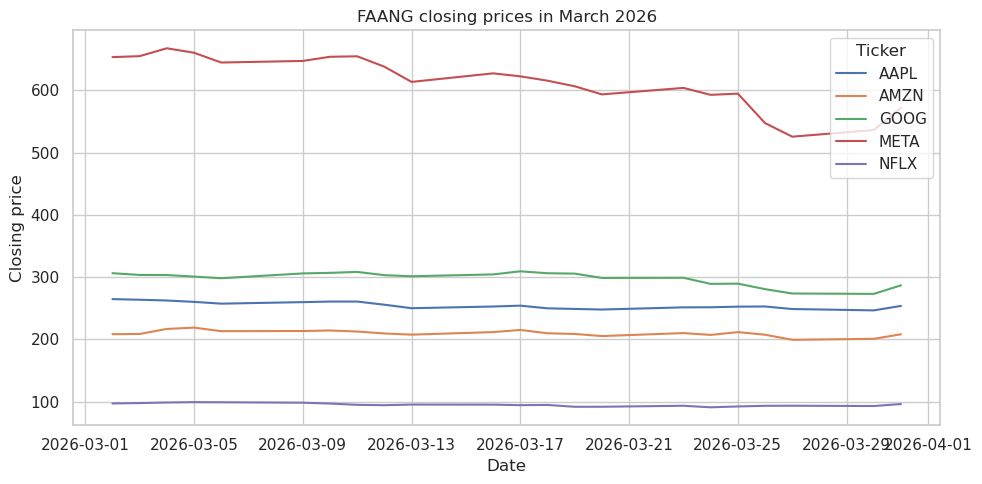

In [12]:
plt.figure(figsize=(10, 5))

sns.lineplot(data=stocks_df, x="date", y="close", hue="symbol")

plt.title("FAANG closing prices in March 2026")
plt.xlabel("Date")
plt.ylabel("Closing price")
plt.legend(title="Ticker")
plt.tight_layout()
plt.show()


### 3b) Bar plot of monthly return percentage per stock

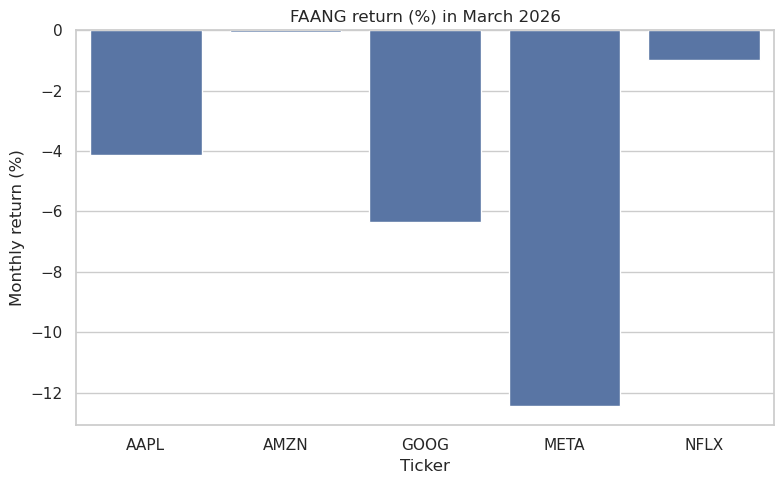

In [13]:
plt.figure(figsize=(8, 5))

sns.barplot(x=performance_df.index, y=performance_df["return_pct"].values)

plt.title("FAANG return (%) in March 2026")
plt.xlabel("Ticker")
plt.ylabel("Monthly return (%)")
plt.tight_layout()
plt.show()


### 3c) Heatmap of daily trading volume

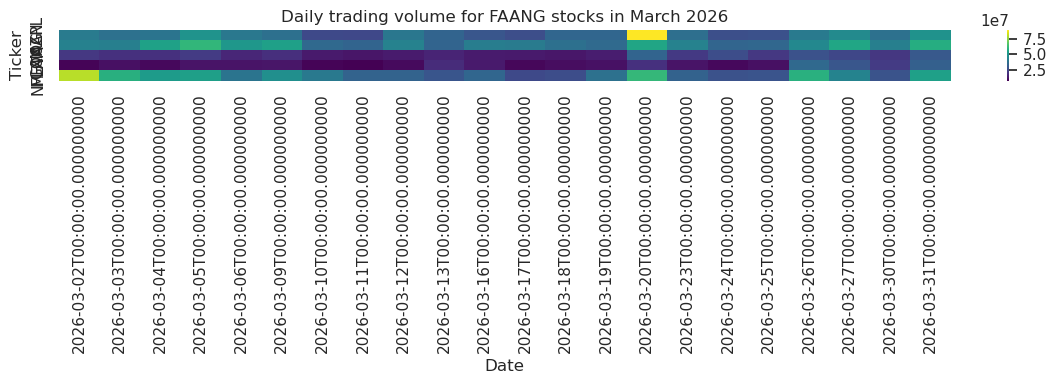

In [14]:
volume_pivot = stocks_df.pivot_table(
    index="symbol",
    columns="date",
    values="volume"
)

plt.figure(figsize=(12, 4))

sns.heatmap(volume_pivot, cmap="viridis")

plt.title("Daily trading volume for FAANG stocks in March 2026")
plt.xlabel("Date")
plt.ylabel("Ticker")
plt.tight_layout()
plt.show()


## Task 4: Exporting and importing data (1p)

We export the raw JSON and the `stocks_df` DataFrame, then load them back and verify the first rows.


### 4a) Export JSON to `exports/stockdata.json`

In [15]:
os.makedirs("exports", exist_ok=True)

with open("exports/stockdata.json", "w") as f:
    json.dump(raw_json, f)


### 4b) Export DataFrame to `exports/stockdata.csv`

In [16]:
stocks_df.to_csv('exports/stockdata.csv', index=False)

### 4c) Load back exported data and show first rows

In [17]:
# Load JSON
with open("exports/stockdata.json", "r") as f:
    loaded_json = json.load(f)

loaded_records = loaded_json.get("data", [])
loaded_df_from_json = pd.DataFrame(loaded_records)
print(loaded_df_from_json.head())

# Load CSV
loaded_df_from_csv = pd.read_csv("exports/stockdata.csv")
print(loaded_df_from_csv.head())


      open    high      low   close      volume  adj_high  adj_low  adj_close  \
0  247.890  255.48  247.101  253.79  48770963.0    255.48  247.101     253.79   
1  204.875  210.28  204.140  208.27  57843337.0    210.28  204.140     208.27   
2  277.840  287.05  276.810  286.86  30680107.0    287.05  276.760     286.86   
3  549.980  573.69  546.770  572.13  32809500.0    573.69  546.770     572.13   
4   93.250   96.26   93.170   96.15  53674277.0     96.26   93.030      96.15   

   adj_open  adj_volume  split_factor  dividend symbol exchange  \
0   247.910  49598091.0           1.0       0.0   AAPL     XNAS   
1   204.845  58470078.0           1.0       0.0   AMZN     XNAS   
2   277.540  31625057.0           1.0       0.0   GOOG     XNAS   
3   549.980  32898272.0           1.0       0.0   META     ARCX   
4    93.030  54269957.0           1.0       0.0   NFLX     XNAS   

                       date  
0  2026-03-31T00:00:00+0000  
1  2026-03-31T00:00:00+0000  
2  2026-03-31T00:00:

## Task 5: Querying the Northwind database (1p)

We use the SQLite version of Microsoft's Northwind database. Download the `northwind.db` file and store it, for example, in a `data/` folder.


### 5a) Connect and list all tables

In [19]:
# Adjust the path to your northwind.db file
northwind_path = Path("data/northwind.db")

conn = sqlite3.connect(northwind_path)

# List all tables
tables_query = "SELECT name FROM sqlite_master WHERE type='table';"
tables_df = pd.read_sql_query(tables_query, conn)
print(tables_df)


                    name
0             Categories
1        sqlite_sequence
2   CustomerCustomerDemo
3   CustomerDemographics
4              Customers
5              Employees
6    EmployeeTerritories
7          Order Details
8                 Orders
9               Products
10               Regions
11              Shippers
12             Suppliers
13           Territories


### 5b) Products with unit price above 30

In [24]:
query_5b = """SELECT ProductName, UnitPrice, UnitsInStock
FROM Products
WHERE UnitPrice > 30;"""

products_high_price = pd.read_sql_query(query_5b, conn)
print(products_high_price)


                   ProductName  UnitPrice  UnitsInStock
0   Northwoods Cranberry Sauce      40.00             6
1              Mishi Kobe Niku      97.00            29
2                        Ikura      31.00            31
3    Queso Manchego La Pastora      38.00            86
4                 Alice Mutton      39.00             0
5             Carnarvon Tigers      62.50            42
6       Sir Rodney's Marmalade      81.00            40
7          Gumbär Gummibärchen      31.23            15
8           Schoggi Schokolade      43.90            49
9            Rössle Sauerkraut      45.60            26
10     Thüringer Rostbratwurst     123.79             0
11          Mascarpone Fabioli      32.00             9
12               Côte de Blaye     263.50            17
13                 Ipoh Coffee      46.00            17
14       Manjimup Dried Apples      53.00            20
15               Perth Pasties      32.80             0
16      Gnocchi di nonna Alice      38.00       

### 5c) Orders to Germany with line totals

Join `Orders`, `Customers`, and `Order Details` to show CompanyName, OrderID, OrderDate, ShipCountry, and line total.


In [26]:
query_5c = """SELECT c.CompanyName,
       o.OrderID,
       o.OrderDate,
       o.ShipCountry,
       od.UnitPrice * od.Quantity AS LineTotal
FROM Orders o
JOIN Customers c ON o.CustomerID = c.CustomerID
JOIN "Order Details" od ON o.OrderID = od.OrderID
WHERE o.ShipCountry = 'Germany';"""

germany_orders = pd.read_sql_query(query_5c, conn)
print(germany_orders.head())


          CompanyName  OrderID   OrderDate ShipCountry  LineTotal
0  Toms Spezialitäten    10249  2016-07-05     Germany      167.4
1  Toms Spezialitäten    10249  2016-07-05     Germany     1696.0
2  Ottilies Käseladen    10260  2016-07-19     Germany      123.2
3  Ottilies Käseladen    10260  2016-07-19     Germany      780.0
4  Ottilies Käseladen    10260  2016-07-19     Germany      591.0


## Task 6: Visualizing Northwind data (1p)

We create visualizations using the query results from Task 5.


### 6a) Bar plot: number of orders per customer (top 10, Germany)

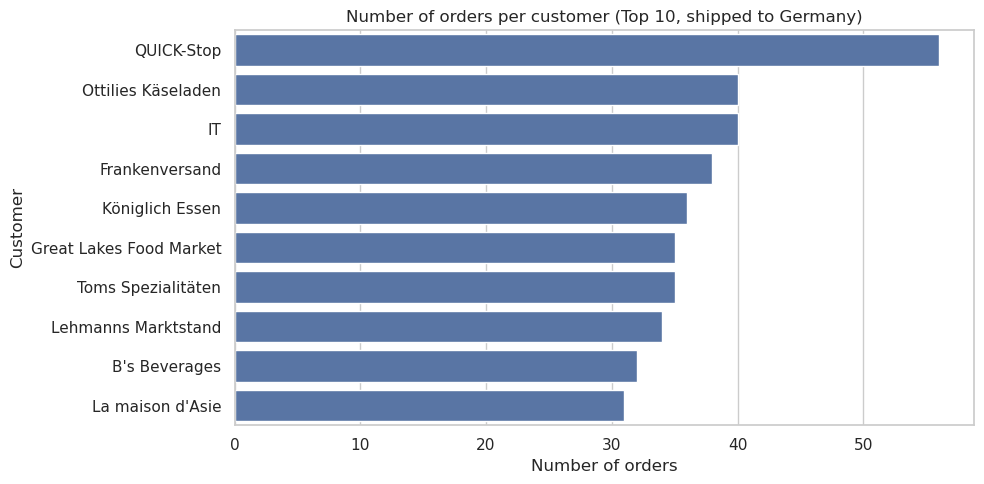

In [27]:
# Number of distinct orders per customer
orders_per_customer = (
    germany_orders.groupby("CompanyName")["OrderID"]
    .nunique()
    .sort_values(ascending=False)
)

Top10 = orders_per_customer.head(10)

plt.figure(figsize=(10, 5))

sns.barplot(x=Top10.values, y=Top10.index, orient="h")

plt.title("Number of orders per customer (Top 10, shipped to Germany)")
plt.xlabel("Number of orders")
plt.ylabel("Customer")
plt.tight_layout()
plt.show()


### 6b) KDE plot: distribution of daily total sales to Germany

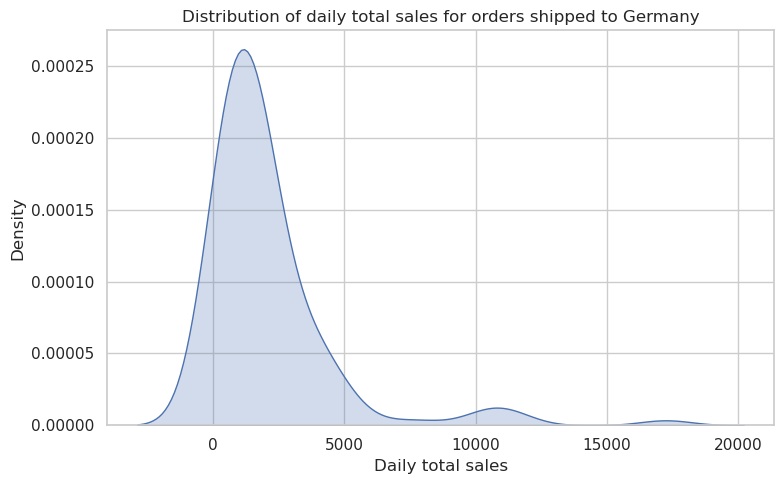

In [29]:
# Ensure OrderDate is datetime - specify format or use errors='coerce'
germany_orders["OrderDate"] = pd.to_datetime(germany_orders["OrderDate"], errors='coerce')

sales_per_date = germany_orders.groupby("OrderDate")["LineTotal"].sum().reset_index()

plt.figure(figsize=(8, 5))

sns.kdeplot(data=sales_per_date, x="LineTotal", fill=True)

plt.title("Distribution of daily total sales for orders shipped to Germany")
plt.xlabel("Daily total sales")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

### 6c) Total revenue per product category (SQL + bar plot)

     CategoryName  TotalRevenue
0       Beverages   92181842.95
1      Condiments   55802774.45
2     Confections   66347544.94
3  Dairy Products   58034940.00
4  Grains/Cereals   28573512.55
5    Meat/Poultry   64896314.41
6         Produce   32706403.90
7         Seafood   49931965.52


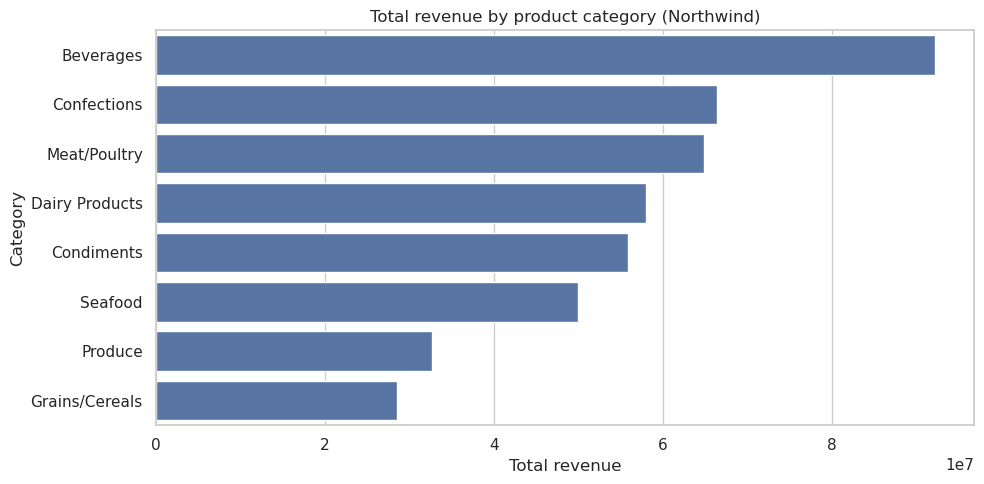

In [33]:
query_6c = """SELECT cat.CategoryName,
       SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM "Order Details" od
JOIN Products p ON od.ProductID = p.ProductID
JOIN Categories cat ON p.CategoryID = cat.CategoryID
GROUP BY cat.CategoryName;"""

revenue_by_category = pd.read_sql_query(query_6c, conn)
print(revenue_by_category)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=revenue_by_category.sort_values("TotalRevenue", ascending=False),
    x="TotalRevenue",
    y="CategoryName",
    orient="h"
)

plt.title("Total revenue by product category (Northwind)")
plt.xlabel("Total revenue")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


## Task 7: Comparing Python to SQL (1p)

We compare doing the aggregation in SQL versus in Python/pandas after loading tables.


### 7a) Retrieve full Products and Categories tables

In [34]:
query_products = "SELECT * FROM Products;"
query_categories = "SELECT * FROM Categories;"

products_df = pd.read_sql_query(query_products, conn)
categories_df = pd.read_sql_query(query_categories, conn)

print(products_df.head())
print(categories_df.head())


   ProductID                   ProductName  SupplierID  CategoryID  \
0          1                          Chai           1           1   
1          2                         Chang           1           1   
2          3                 Aniseed Syrup           1           2   
3          4  Chef Anton's Cajun Seasoning           2           2   
4          5        Chef Anton's Gumbo Mix           2           2   

       QuantityPerUnit  UnitPrice  UnitsInStock  UnitsOnOrder  ReorderLevel  \
0   10 boxes x 20 bags      18.00            39             0            10   
1   24 - 12 oz bottles      19.00            17            40            25   
2  12 - 550 ml bottles      10.00            13            70            25   
3       48 - 6 oz jars      22.00            53             0             0   
4             36 boxes      21.35             0             0             0   

  Discontinued  
0            0  
1            0  
2            0  
3            0  
4            1  
  

### 7b) Inner join in pandas on CategoryID

In [35]:
products_categories_df = products_df.merge(categories_df, on="CategoryID", how="inner")
products_categories_df.head()


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued,CategoryName,Description,Picture
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


### 7c) Compare execution speed: SQL vs Python/pandas

In [38]:
# 1) SQL-only version (reusing query_6c)
start_sql = time.time()
revenue_by_category_sql = pd.read_sql_query(query_6c, conn)
end_sql = time.time()
sql_time = end_sql - start_sql
print("SQL approach time (seconds):", sql_time)

# 2) Python/pandas version
start_py = time.time()


order_details_df = pd.read_sql_query('SELECT * FROM [Order Details];', conn)

joined_df = (
    order_details_df
    .merge(products_df, on="ProductID", how="inner")
    .merge(categories_df, on="CategoryID", how="inner")
)

# Adjust column names if needed depending on how pandas names UnitPrice
revenue_by_category_py = (
    joined_df
    .assign(LineTotal=lambda df_: df_["UnitPrice_x"] * df_["Quantity"])
    .groupby("CategoryName")["LineTotal"]
    .sum()
    .reset_index(name="TotalRevenue")
)

end_py = time.time()
py_time = end_py - start_py
print("Python/pandas approach time (seconds):", py_time)

SQL approach time (seconds): 1.2174174785614014
Python/pandas approach time (seconds): 2.42160964012146


## Task 8: Wide and long format (1p)

We work with simple toy datasets to practice converting between wide and long formats.


### 8a) Convert `wide_data` from wide to long using `pd.melt()`

In [40]:
wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})

print("Original wide_data:")
print(wide_data)

long_sales = pd.melt(
    wide_data,
    id_vars="store",
    value_vars=["Q1_sales", "Q2_sales", "Q3_sales", "Q4_sales"],
    var_name="quarter",
    value_name="sales"
)

# Fixed the syntax error by making the string continuous without a newline
print("Long format (long_sales):")
print(long_sales)

Original wide_data:
      store  Q1_sales  Q2_sales  Q3_sales  Q4_sales
0  Helsinki     12000     13500     11800     15000
1   Tampere      8500      9100      8800     10200
2     Turku      9200      9800     10100     11500
Long format (long_sales):
       store   quarter  sales
0   Helsinki  Q1_sales  12000
1    Tampere  Q1_sales   8500
2      Turku  Q1_sales   9200
3   Helsinki  Q2_sales  13500
4    Tampere  Q2_sales   9100
5      Turku  Q2_sales   9800
6   Helsinki  Q3_sales  11800
7    Tampere  Q3_sales   8800
8      Turku  Q3_sales  10100
9   Helsinki  Q4_sales  15000
10   Tampere  Q4_sales  10200
11     Turku  Q4_sales  11500


### 8b) Convert `long_data` from long to wide using `.pivot()`

In [42]:
long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})

print("Original long_data:")
print(long_data)

wide_units = long_data.pivot(
    index="month",
    columns="product",
    values="units_sold"
).reset_index()

print("Wide format (wide_units):")  # Fixed the string by removing the newline
print(wide_units)

Original long_data:
  month product  units_sold
0   Jan  Laptop          45
1   Jan   Phone         120
2   Feb  Laptop          50
3   Feb   Phone         110
4   Mar  Laptop          55
5   Mar   Phone         130
Wide format (wide_units):
product month  Laptop  Phone
0         Feb      50    110
1         Jan      45    120
2         Mar      55    130


### 8c) Convert both transformed datasets back to their original format

In [43]:
# From long_sales back to wide_data
wide_data_reconstructed = long_sales.pivot(
    index="store",
    columns="quarter",
    values="sales"
).reset_index()

print("Reconstructed wide_data:")
print(wide_data_reconstructed)

# From wide_units back to long_data
wide_units_indexed = wide_units.set_index("month")

long_data_reconstructed = wide_units_indexed.reset_index().melt(
    id_vars="month",
    value_vars=[col for col in wide_units_indexed.columns],
    var_name="product",
    value_name="units_sold"
)

print("Reconstructed long_data (sorted):")
print(long_data_reconstructed.sort_values(["month", "product"]))


Reconstructed wide_data:
quarter     store  Q1_sales  Q2_sales  Q3_sales  Q4_sales
0        Helsinki     12000     13500     11800     15000
1         Tampere      8500      9100      8800     10200
2           Turku      9200      9800     10100     11500
Reconstructed long_data (sorted):
  month product  units_sold
0   Feb  Laptop          50
3   Feb   Phone         110
1   Jan  Laptop          45
4   Jan   Phone         120
2   Mar  Laptop          55
5   Mar   Phone         130
